# Policy iteration and value iteration for the four room problem


#### Four rooms
- This is a classic example from a paper of Sutton
- https://people.cs.umass.edu/~barto/courses/cs687/Sutton-Precup-Singh-AIJ99.pdf

- "As a simple illustration of planning with options, consider the rooms example, a gridworld environment of four rooms as shown in Fig. 2. The cells of the grid correspond to the states of the environment. From any state the agent can perform one of four actions, up, down, left or right, which have a stochastic effect. With probability 2/3, the actions cause the agent to move one cell in the corresponding direction, and with probability 1/3, the agent moves instead in one of the other three directions, each with probability 1/9. In either case, if the movement would take the agent into a wall then the agent remains in the same cell. For now we consider a case in which rewards are zero on all state transitions"

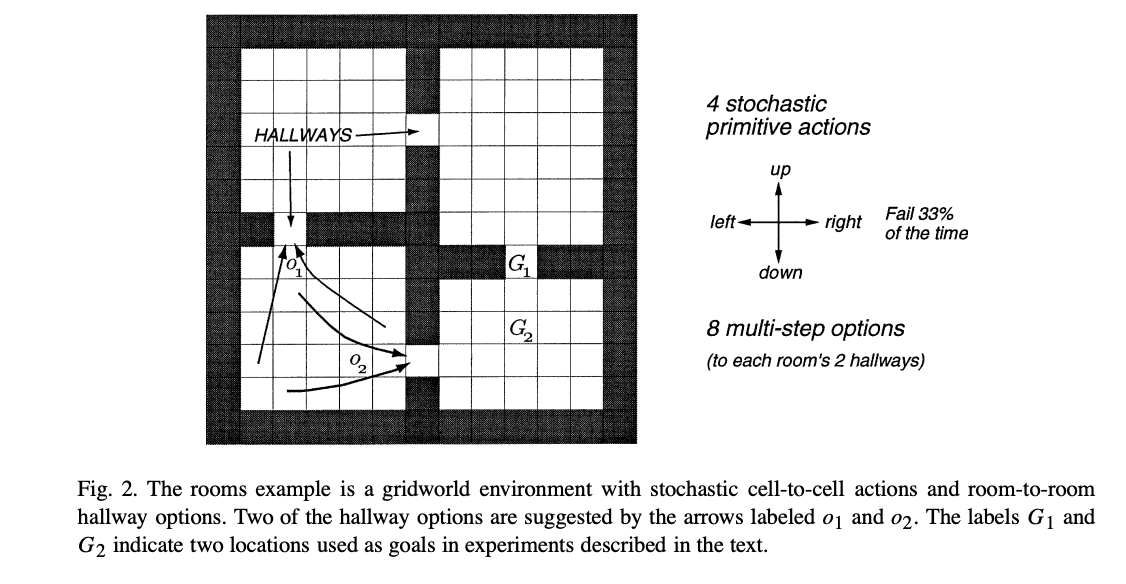

## Base class of the four room problem using `gymnasium`  (no need to change)

In [32]:

import random
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
class FourRoomEnv(gym.Env):
    """
    Classic four-room gridworld.
    Grid: 11x11, rooms separated by walls with doorways.
    State: (row, col) position of the agent
    Action: 0=up, 1=right, 2=down, 3=left
    Reward: -1 per step, +10 at goal
    slippage: a scaler. If slippage != 0, with probability 1-slippage, it performs the action specified, 
    .         and with slippage/3, takes one of the other 3 actions
    """
    metadata = {"render_modes": ["ansi"], "render_fps": 2}

    def __init__(self, render_mode=None, slippage = 0.):
        super().__init__()
        self.grid_size = 13
        self.action_space = gym.spaces.Discrete(4)
        self.observation_space = gym.spaces.MultiDiscrete([self.grid_size, self.grid_size])
        self.agent_pos = [1, 1]
        self.goal_pos = [11, 11]
        self.render_mode = render_mode
        self.slippage = slippage

        # Walls: 1 = wall, 0 = empty
        self.walls = np.zeros((self.grid_size, self.grid_size), dtype=int)
        self._build_walls()

    def _build_walls(self):
        # Add outer walls
        self.walls[0, :] = 1
        self.walls[-1, :] = 1
        self.walls[:, 0] = 1
        self.walls[:, -1] = 1

        # Add inner walls to make four rooms
        self.walls[:, 6] = 1
        self.walls[6, 1:6] = 1
        self.walls[7, 6:13] = 1
        

        # Doors (openings in walls)
        self.walls[2, 6] = 0
        self.walls[10, 6] = 0
        self.walls[6, 2] = 0
        self.walls[7, 9] = 0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.agent_pos = [1, 1]
        return np.array(self.agent_pos), {}

    def step(self, action):
        moves = {0: (-1, 0), 1: (0, 1), 2: (1, 0), 3: (0, -1)}
        # Implement code here to do this:
        # "With probability 2/3, the actions cause the agent to move one cell in the 
        # corresponding direction, and with probability 1/3, the agent moves instead in 
        # one of the other three directions, each with probability 1/9."
        # But use self.slippage in place of 1/3
        if random.random() < self.slippage:
            actions = list(moves.keys())
            actions.remove(action)
            action = random.choice(actions)
        delta = moves[action]

        new_pos = [self.agent_pos[0] + delta[0], self.agent_pos[1] + delta[1]]

        # Check collision with walls
        if self.walls[new_pos[0], new_pos[1]] == 0:
            self.agent_pos = new_pos

        reward = 10 if self.agent_pos == self.goal_pos else 0
        done = self.agent_pos == self.goal_pos
        return np.array(self.agent_pos), reward, done, False, {}

    def render(self):
        if self.render_mode != "ansi":
            return
        grid = np.where(self.walls == 1, "#", ".")
        grid[tuple(self.agent_pos)] = "A"
        grid[tuple(self.goal_pos)] = "G"
        print("\n".join("".join(row) for row in grid))
        print()


## Problem 1 (20pts). Policy evaluation class that extends the four room, also incoude some utility function for later use. You need to complete one line of code below.

In [ ]:
class FourRoomEnv_Policy_Evaluation(FourRoomEnv):
    def __init__(self, render_mode=None, slippage = 0., gamma = 1.0, verbose = False):
        super().__init__(render_mode = render_mode, slippage = slippage)
        self.v = np.zeros((self.grid_size, self.grid_size), dtype=float)
        self.moves = {0: (-1, 0), 1: (0, 1), 2: (1, 0), 3: (0, -1)}
        self.actions = list(self.moves.keys())#[0, 1, 2, 3]
        self.gamma = gamma
        self.states = [(i, j) for i in range(self.grid_size) for j in range(self.grid_size) 
                       if self.walls[i, j] == 0]
        self.verbose = verbose

    def dynamics(self, s, a): #this calculates P(s', r|s, a), it return [[s', r, p],...]   
        p_slip = self.slippage/(len(self.moves) - 1)
        policy = [[a2, 1 - self.slippage if a2 == a else p_slip] for a2 in self.actions]
        policy = [x for x in policy if x[1] != 0]
        res = []
        for [a2, p] in policy:
            delta = self.moves[a2]
            new_pos = (s[0] + delta[0], s[1] + delta[1])
            # Check collision with walls
            if self.walls[new_pos[0], new_pos[1]] == 1:
                new_pos = s
            reward = 10 if list(new_pos) == self.goal_pos else 0
            res.append([new_pos, reward, p])
        return res
    
    def policy_evaluation(self, policy, epsilon = 0.0001, max_iter = 1000):# v after one policy used to calculate
        # policy(s) gives [[a, p],...]
        for iter in range(max_iter):
            vold = self.v.copy()
            for s in self.states:
                if s == tuple(self.goal_pos):
                    self.v[s[0], s[1]] = 0
                    continue
                res = 0
                for a,p in policy(s): # a, P(a|s)
                    for [s2, r, p_dynamics] in self.dynamics(s, a): # s2, r, P(s2, r| s, a)
                        # ========= Your code here, this is the Bellman equation for state values =========
                        res += p * p_dynamics * (r + self.gamma * vold[s2[0], s2[1]])
                self.v[s[0], s[1]] = res
            norm_inf = np.linalg.norm(self.v - vold, np.inf)
            converged = norm_inf < epsilon
            if self.verbose and (converged or iter%100 == 1):
                print(f"iter = {iter}, norm_inf = {norm_inf}")
            if converged:
                break
        return self.v
    
    def bellman_optimality(self):# find the optimal state value function, check equation 
        for s in self.states:
            if s == tuple(self.goal_pos):
                self.v[s[0], s[1]] = 0
                continue
                
            vmax = -np.inf# smaller than any possible value
            for a in self.actions:
                q = 0
                for [s2, r, p_dynamics] in self.dynamics(s, a):
                    q += p_dynamics*(r + self.gamma * self.v[s2[0], s2[1]])
                vmax = max(vmax, q)# q >= vmax
            self.v[s[0], s[1]] = vmax
        return self.v

    def random_policy(self, s):# give out [0, 0.25], [1, 0.25], [2, 0.25], [3, 0.25] for any state s
        return [[a, 0.25] for a in self.actions]
    
    def policy_sameQ(self, p1, p2): # check two policy functions are the same
        for s in self.states:
            if p1(s) != p2(s):
                return False
        return True
    
    def policy_greedy(self):# functional, set a function first then input s
        def greedy_policy(s):
            if s == tuple(self.goal_pos):
                return [[0, 1.0]]
            action_values = []
            for a in self.actions:
                val = 0
                for [s2, r, p_dynamics] in self.dynamics(s, a):
                    val += p_dynamics * (r + self.gamma * self.v[s2[0], s2[1]])
                action_values.append(val)
            a_best = int(np.argmax(action_values))
            return [[a_best, 1.0]]
        return greedy_policy


## Plotting function showing state values and policy (no need to change)

In [23]:
import matplotlib.pyplot as plt


def plot_state_action(v, walls, policy=None, ax=None, title=None, show_colorbar=True):
    nrows, ncols = v.shape

    # If no axis is given, create one (standalone mode)
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
        created_fig = True

    im = ax.imshow(v, origin="upper")

    if show_colorbar and created_fig:
        plt.colorbar(im, ax=ax, fraction=0.046)

    # overlay walls in red
    wall_mask = np.ma.masked_where(walls == 0, walls)
    ax.imshow(wall_mask, cmap="Reds", origin="upper", alpha=0.6)

    action_to_dir = {
        0: (0, -1),   # up
        1: (1, 0),    # right
        2: (0, 1),    # down
        3: (-1, 0),   # left
    }

    if policy is not None:
        for i in range(nrows):
            for j in range(ncols):
                if v[i, j] == 0:
                    continue

                ax.text(j, i, f"{v[i, j]:.1f}",
                        ha="center", va="center",
                        color="white", fontsize=8)

                for a, p in policy((i, j)):
                    if p == 0:
                        continue
                    dx, dy = action_to_dir[a]
                    ax.arrow(
                        j, i,
                        dx * 0.45 * np.sqrt(p),
                        dy * 0.45 * np.sqrt(p),
                        head_width=0.15,
                        head_length=0.15,
                        fc="red",
                        ec="red",
                        length_includes_head=True
                    )

    ax.set_xticks(range(ncols))
    ax.set_yticks(range(nrows))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(True)

    if title is not None:
        ax.set_title(title)

    # IMPORTANT: do not call plt.show() here, don't block other pictures from being drawn in the notebook
    return ax, im

## Problem 2 (15 pts): Policy evaluation
- Let's do evaluation of the random policy
- since there is no penalty and no discount, in theory the state value should be 10 everywhere
- Try max_iter = 100, 1000
- **Does the evaluation converge at iter = 100**
- **Does it converge by 1000**

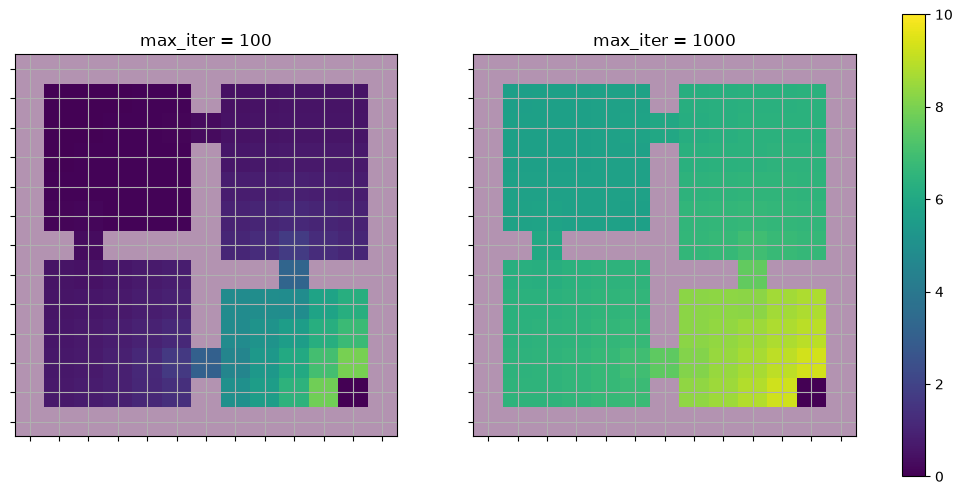

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, k in zip(axes, [100, 1000]):
    env = FourRoomEnv_Policy_Evaluation(slippage=0, gamma=1)   # fresh v = 0
    v = env.policy_evaluation(env.random_policy, max_iter=k, epsilon=1e-5)
    _, im = plot_state_action(v.copy(), env.walls, ax=ax, title=f"max_iter = {k}")
    im.set_clim(0, 10)            # same color scale on both panels

fig.colorbar(im, ax=axes, fraction=0.046)
plt.show()

Answer: Based on the render result, we can see clearly none of the 2 iterations converge.

## Problem 3 (15 pts): Policy evaluation

- **Now change $\gamma$ to 0.9, does it converge faster**?
- **Explain why $\gamma < 1$ converges fater/slower, at a high level**

iter = 1, norm_inf = 1.6875
iter = 93, norm_inf = 9.057834740946319e-06


(<Axes: >, <matplotlib.image.AxesImage at 0x1112a1950>)

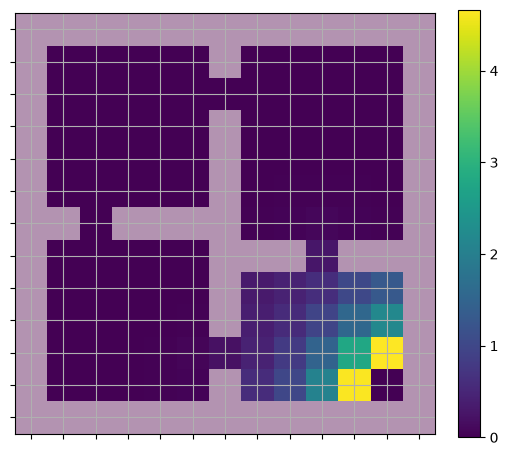

In [27]:
frpi = FourRoomEnv_Policy_Evaluation(slippage = 0, verbose = True, gamma = 0.9)
policy = frpi.random_policy
v = frpi.policy_evaluation(policy, max_iter = 100, epsilon = 0.00001)
plot_state_action(v, frpi.walls, policy = None)

Answer: It converges fast, but since we have discounts, many of the value of block will be close to zero.

Why:$\|v_k - v_\pi\|_\infty \le \gamma^k \|v_0 - v_\pi\|_\infty$, shrink faster.

## Problem 4 (25 pts). Policy iteration
- **Now write a policy iteration loop to find optimal policy**

In [ ]:
def freeze(policy_fn, states):# implement the greedy to each state and store them into a table
    table = {s: policy_fn(s) for s in states}   # compute every action now
    return lambda s: table.get(s, [[0, 1.0]])

iter = 1, norm_inf = 1.6875
iter = 73, norm_inf = 9.442338239248806e-05


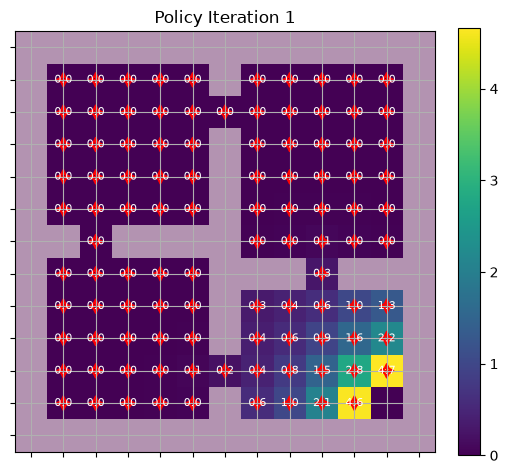

iter = 1, norm_inf = 8.051464311794028
iter = 20, norm_inf = 0.0


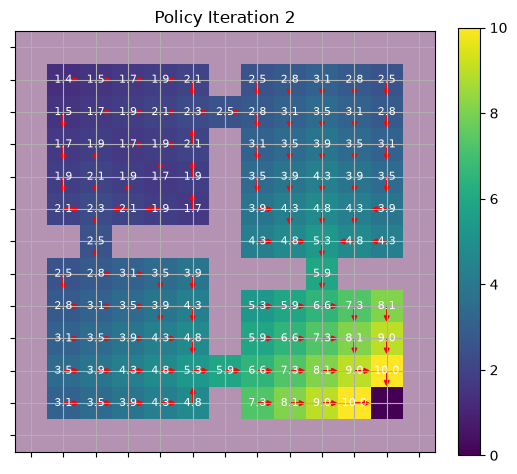

iter = 0, norm_inf = 0.0


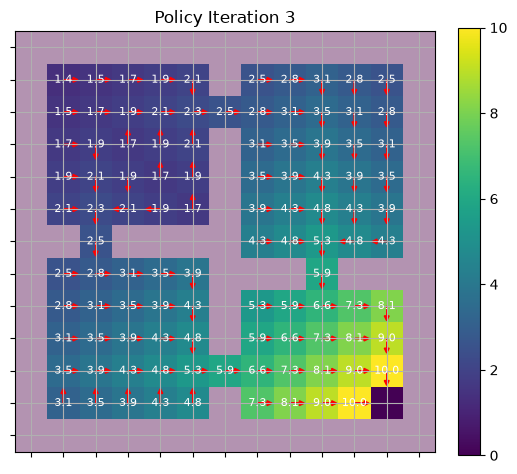

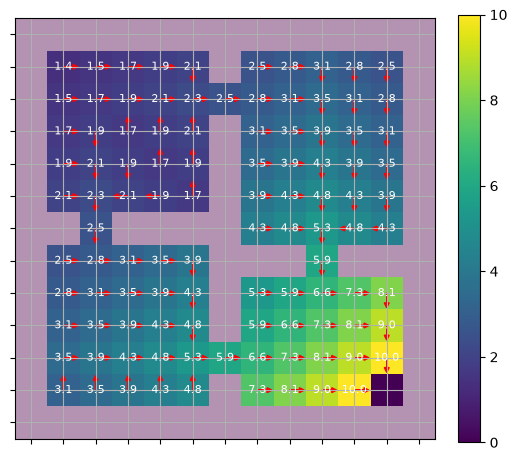

In [38]:
frpi = FourRoomEnv_Policy_Evaluation(render_mode = 'ansi', slippage = 0., verbose = True, gamma = 0.9)
policy = frpi.random_policy
max_policy_iters = 10

for i in range(max_policy_iters):
    # Policy evaluation ======== Your code here ========
    v = frpi.policy_evaluation(policy).copy()
    
    # plot ======== Your code here ========
    plot_state_action(v, frpi.walls, policy,title=f"Policy Iteration {i+1}")
    plt.show()
        
    # Policy improvement (Greedy) ======== Your code here ========
    new_policy = freeze(frpi.policy_greedy(), frpi.states)
        
    # quit if policy unchanged ======== Your code here ========
    if frpi.policy_sameQ(policy, new_policy):
        break
        
    policy = new_policy
    
# plot the final policy to check that policy unchanged
plot_state_action(v, frpi.walls, new_policy)
plt.show()
    

## Problem 5 (25 pts) Value iteration
- **Now write a value iteration loop to find optimal policy**

value iteration -- 0


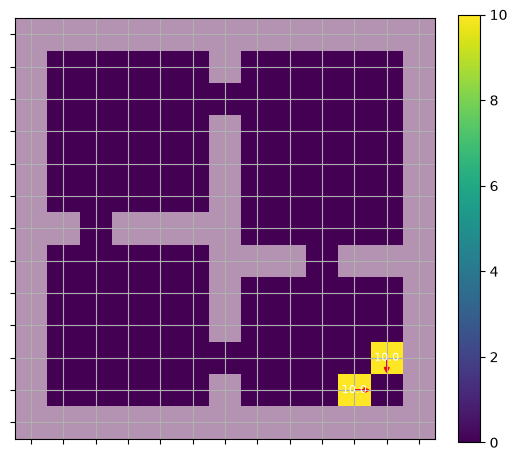

value iteration -- 1


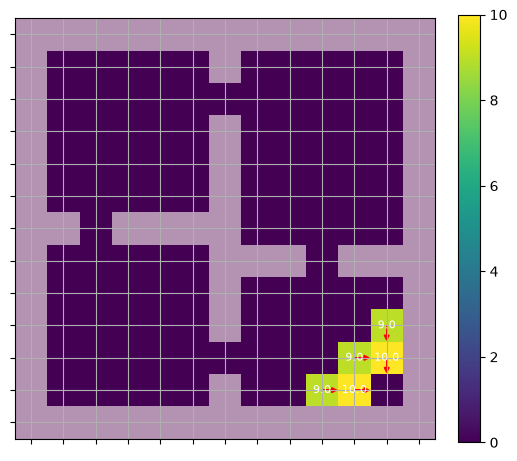

value iteration -- 2


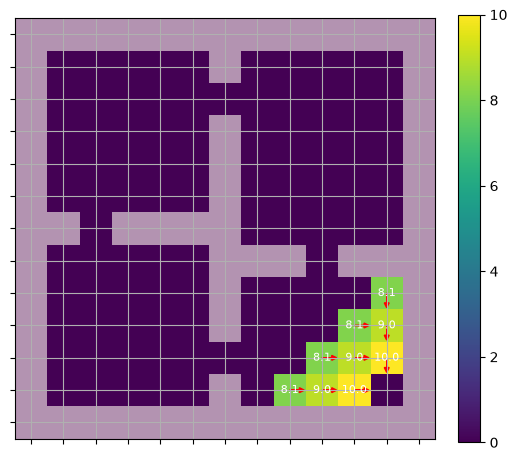

value iteration -- 3


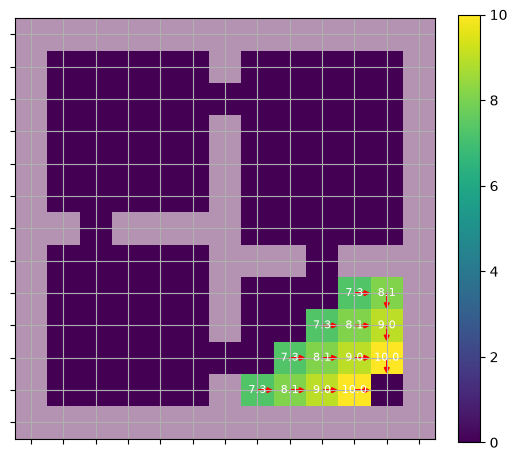

value iteration -- 4


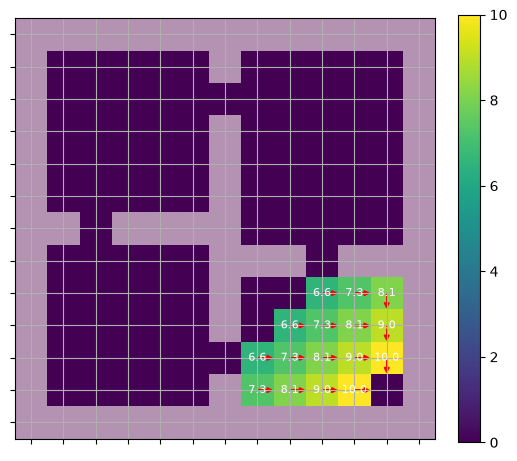

value iteration -- 5


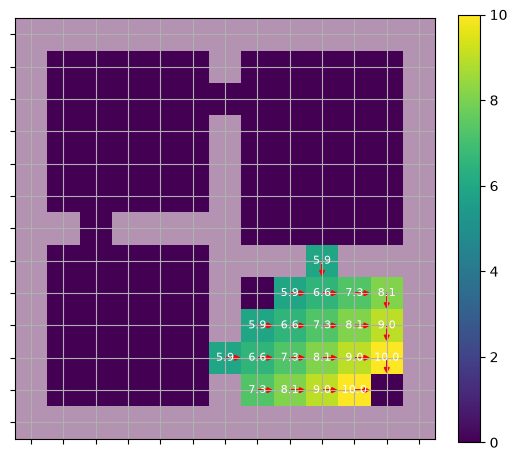

value iteration -- 6


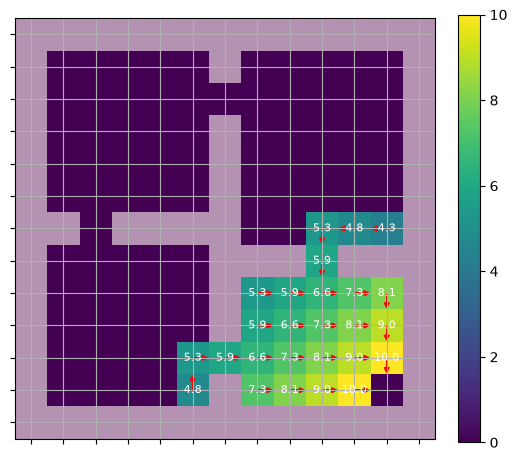

value iteration -- 7


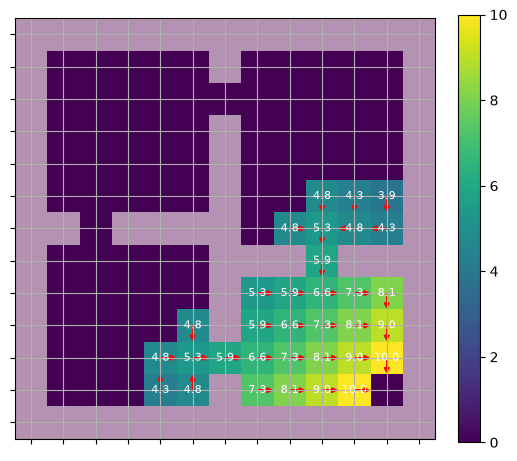

value iteration -- 8


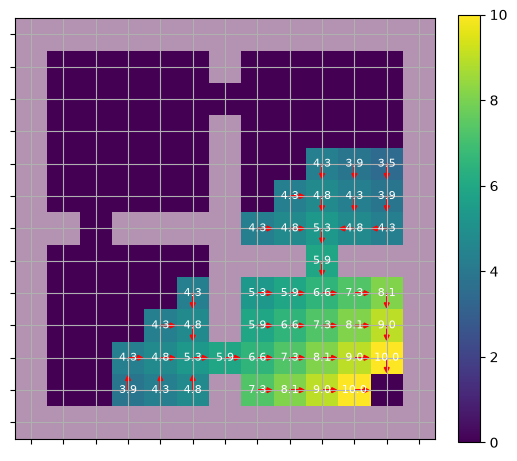

value iteration -- 9


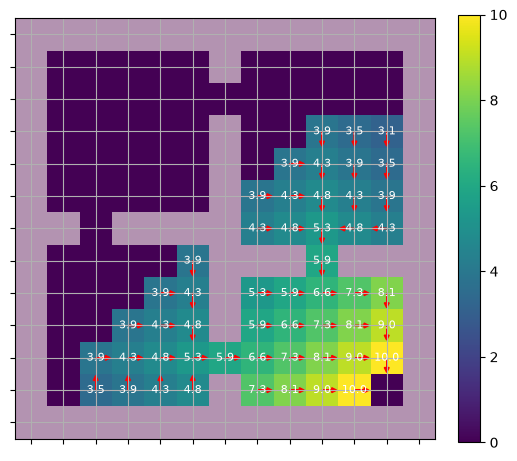

value iteration -- 10


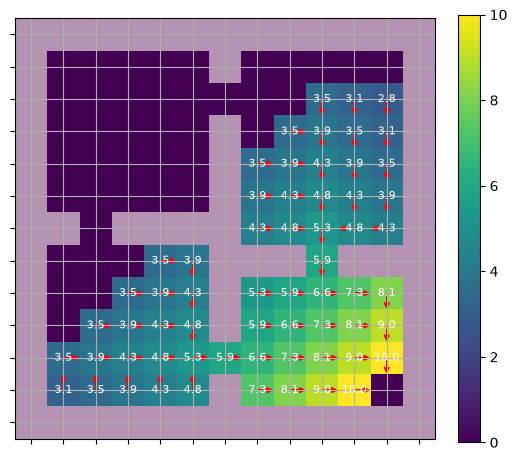

value iteration -- 11


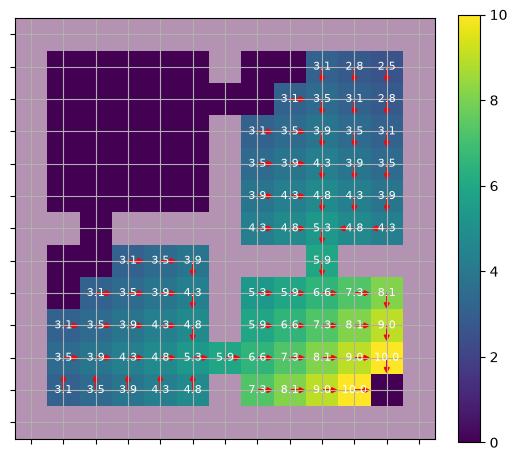

value iteration -- 12


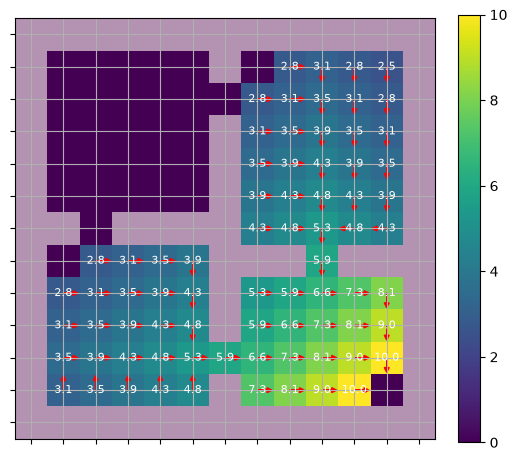

value iteration -- 13


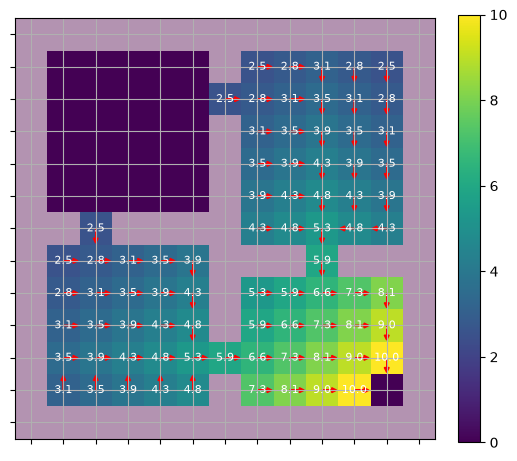

value iteration -- 14


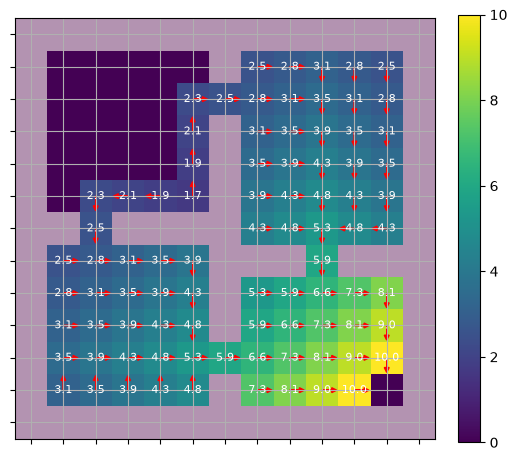

value iteration -- 15


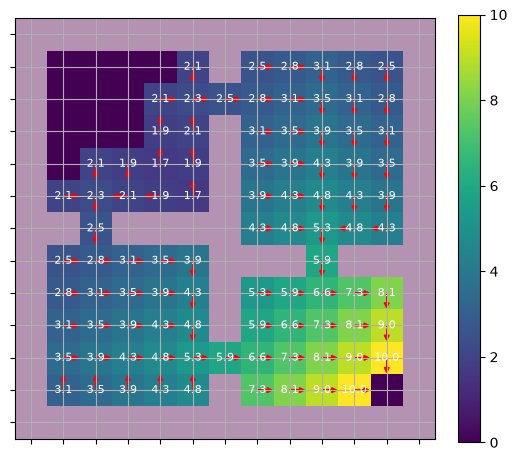

value iteration -- 16


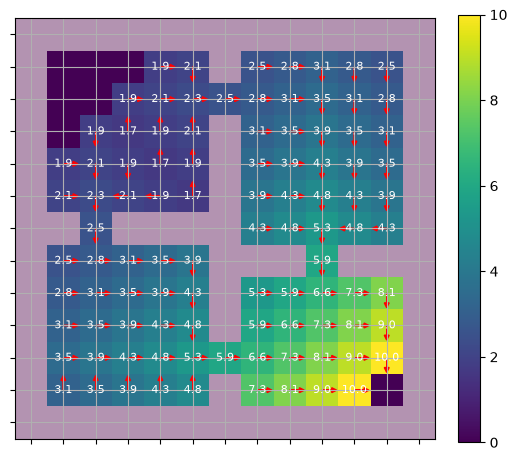

value iteration -- 17


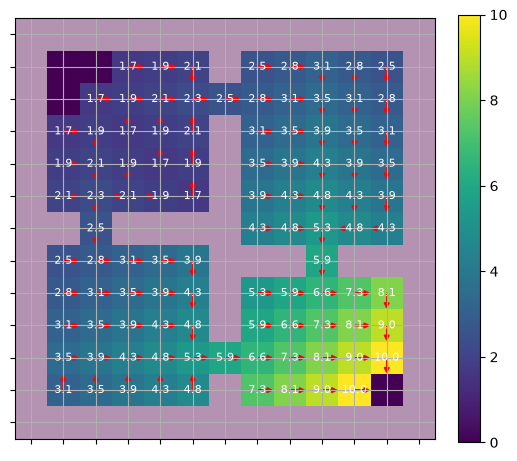

value iteration -- 18


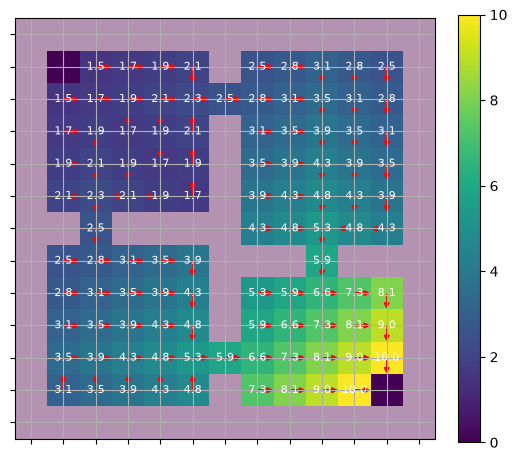

value iteration -- 19


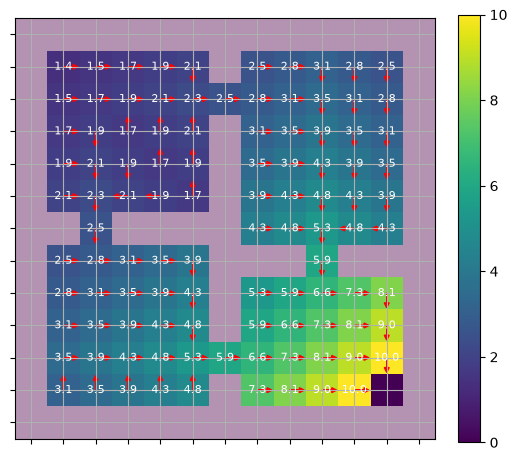

value iteration -- 20


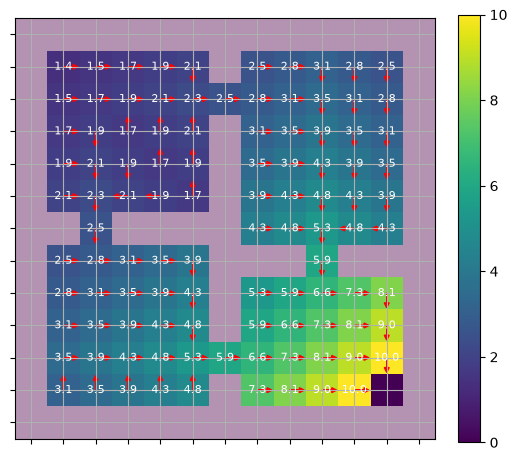

In [37]:
frpi = FourRoomEnv_Policy_Evaluation(render_mode = 'ansi', slippage = 0., verbose = False, gamma = 0.9)
policy = frpi.random_policy
max_value_iters = 100
eps = 0.00001

for i in range(max_value_iters):
    print(f"value iteration -- {i}")
    vold = frpi.v.copy()
    
    # Do one iteration of the bellman optimality equation ======== Your code here ========
    v = frpi.bellman_optimality().copy()
    
    # Get greedy policy, and plot state value + policy ======== Your code here ========
    policy = freeze(frpi.policy_greedy(), frpi.states)
    plot_state_action(v, frpi.walls, policy)
    plt.show()
                
    # quit if state value not changing ======== Your code here ========
    #print(np.linalg.norm(v - vold, np.inf))
    if np.linalg.norm(v - vold, np.inf) < eps:
        break


### Be curious and explore! (not graded)
- Change the Bellman optimality equation to use synchronous update, what do you observe?
- Set slipperage to > 0, what do you observe?

In [34]:
! python -m jupyter nbconvert 06_Dynamic_Programming_hw.ipynb --to webpdf

[NbConvertApp] Converting notebook 06_Dynamic_Programming_hw.ipynb to webpdf
[NbConvertApp] WARNING | Alternative text is missing on 24 image(s).
[NbConvertApp] Building PDF
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 1093099 bytes to 06_Dynamic_Programming_hw.pdf
